# GRPO JSON Extraction with Fireworks Training API

Fine-tunes Qwen3-8B for structured JSON invoice extraction using GRPO via the Fireworks Training API. The training loop runs from this notebook. The model trains on remote GPUs managed by Fireworks.

| Step | What it does |
|------|--------------|
| 0 | Install dependencies and load keys |
| 1 | Define the reward function |
| 2 | Upload the training dataset |
| 3 | Baseline eval on base Qwen3-8B |
| 4 | GRPO training loop |
| 5 | Post-training eval on fine-tuned model |
| 6 | GPT-4.1 comparison eval |
| 7 | Inference on the deployed model |

---

## Step 0 - Setup

Clone the Fireworks cookbook, install dependencies, and load keys from `.env`.

In [ ]:
# Clone the Fireworks cookbook first:
# git clone https://github.com/fw-ai/cookbook.git

!uv pip install python-dotenv jsonschema openai fireworks-ai matplotlib
!uv pip install -e "cookbook/training[training]"
!uv pip install eval-protocol nest_asyncio

Using Python 3.13.11 environment at: fireworks
Audited 4 packages in 17ms


In [40]:
import os
import sys
import json
import time
from pathlib import Path
from dotenv import load_dotenv

load_dotenv()

FIREWORKS_KEY  = os.getenv("FIREWORKS_API_KEY")
OPENROUTER_KEY = os.getenv("OPENROUTER_API_KEY")
ACCOUNT_ID     = os.getenv("FIREWORKS_ACCOUNT_ID")

os.environ["FIREWORKS_API_KEY"] = FIREWORKS_KEY

assert FIREWORKS_KEY,  "Missing FIREWORKS_API_KEY"
assert OPENROUTER_KEY, "Missing OPENROUTER_API_KEY"
assert ACCOUNT_ID,     "Missing FIREWORKS_ACCOUNT_ID"

print("Ready ✓")

Ready ✓


---
## Step 1 - Reward Function

Scores each model completion against the invoice schema.

| Score | Condition |
|-------|-----------|
| `0.0` | Output does not parse as JSON |
| `0.5` | Valid JSON but fails schema validation |
| `1.0` | Valid JSON, fully conforms to schema |

During training, `rl_loop` calls `score()` against every completion automatically.

In [38]:
from jsonschema import validate, ValidationError

SCHEMA = {
    "type": "object",
    "required": ["vendor", "date", "amount", "currency"],
    "properties": {
        "vendor":   {"type": "string"},
        "date":     {"type": "string"},
        "amount":   {"type": "number"},
        "currency": {"type": "string"},
    },
    "additionalProperties": False
}

def score(completion: str) -> float:
    try:
        parsed = json.loads(completion.strip())
    except (json.JSONDecodeError, ValueError):
        return 0.0
    try:
        validate(instance=parsed, schema=SCHEMA)
        return 1.0
    except ValidationError:
        return 0.5

assert score('{"vendor": "Acme Corp", "date": "2024-01-15", "amount": 1250.00, "currency": "USD"}') == 1.0
assert score('{"vendor": "Acme Corp", "date": "2024-01-15"}') == 0.5
assert score('not json') == 0.0
print("Reward function OK ✓")

Reward function OK ✓


---
## Step 2 - Upload Training Dataset

Uploads `train_prompts.jsonl` to Fireworks and waits for `READY` state before the training job can reference it.

The dataset is 200 input prompts covering invoice variation across date formats, amount formats, currencies, and vendor names. No labeled outputs needed - GRPO generates its own completions during training and scores them.

In [ ]:
from fireworks import Fireworks

fw_client = Fireworks(api_key=FIREWORKS_KEY)

DATASET_ID = "invoice-extraction-grpo-v1"
TRAIN_FILE = Path("./train_prompts.jsonl")

assert TRAIN_FILE.exists(), f"File not found: {TRAIN_FILE}"

row_count = sum(1 for _ in open(TRAIN_FILE))
print(f"Uploading {row_count} prompts as '{DATASET_ID}'...")

fw_client.datasets.create(
    dataset_id=DATASET_ID,
    dataset={"exampleCount": str(row_count)}
)
fw_client.datasets.upload(dataset_id=DATASET_ID, file=TRAIN_FILE)

print("Waiting for READY", end="")
while True:
    ds = fw_client.datasets.get(dataset_id=DATASET_ID)
    if ds.state == "READY":
        print(" ✓")
        break
    print(".", end="", flush=True)
    time.sleep(3)

print(f"Dataset '{DATASET_ID}' state: {ds.state}")
print("Ready to proceed to training ✓")

Dataset 'invoice-extraction-grpo-v1' state: READY
Ready to proceed to training ✓


---
## Step 3 - Baseline Eval (Run Before Training)

Evaluates base Qwen3-8B on 50 held-out prompts before any fine-tuning. This is the before number.

Called via OpenRouter using the same `score()` function and eval set used in Step 5.

In [ ]:
from openai import OpenAI

or_client = OpenAI(
    api_key=OPENROUTER_KEY,
    base_url="https://openrouter.ai/api/v1"
)

eval_data = [json.loads(l) for l in open("./eval_prompts.jsonl")]
print(f"Eval prompts: {len(eval_data)}")

def run_eval(client, model_id: str, label: str) -> float:
    scores = []
    for i, entry in enumerate(eval_data):
        messages = [m for m in entry["messages"] if m["role"] != "assistant"]
        # Suppress thinking mode for structured output
        messages = [
            {**m, "content": m["content"] + " /no-think"}
            if m["role"] == "system" else m
            for m in messages
        ]
        try:
            response = client.chat.completions.create(
                model=model_id,
                messages=messages,
                temperature=0.0,
                max_tokens=512,
            )
            content = response.choices[0].message.content
            if "</think>" in content:
                content = content.split("</think>")[-1].strip()
            s = score(content)
        except Exception as e:
            print(f"  Error on prompt {i}: {e}")
            s = 0.0
        scores.append(s)
        if (i + 1) % 10 == 0:
            acc = sum(1 for s in scores if s == 1.0) / len(scores)
            print(f"  [{label}] {i+1}/{len(eval_data)} running: {acc:.1%}")

    accuracy = sum(1 for s in scores if s == 1.0) / len(scores)
    print(f"\n[{label}] Schema-valid: {accuracy:.1%} ({sum(1 for s in scores if s == 1.0)}/{len(scores)})")
    return accuracy

baseline_accuracy = run_eval(or_client, "qwen/qwen3-8b", label="BASE Qwen3-8B")

Eval prompts: 50
  [BASE Qwen3-8B] 10/50 running: 40.0%
  [BASE Qwen3-8B] 20/50 running: 45.0%
  [BASE Qwen3-8B] 30/50 running: 53.3%
  [BASE Qwen3-8B] 40/50 running: 57.5%
  [BASE Qwen3-8B] 50/50 running: 62.0%

[BASE Qwen3-8B] Schema-valid: 62.0% (31/50)


---
## Step 4 - GRPO Training Loop

Runs the full GRPO training loop via the Fireworks Training API.

| Parameter | Value | Note |
|-----------|-------|------|
| `completions_per_prompt` | 4 | Completions generated per prompt per step |
| `epochs` | 1 | Single pass over the dataset |
| `weight_sync_interval` | 1 | Syncs inference deployment with training checkpoint every step |
| `dcp_save_interval` | 50 | Checkpoint saved every 50 steps |

The fine-tuned model is automatically deployed to `accounts/{ACCOUNT_ID}/models/invoice-extractor-v1` when training completes.

In [ ]:
import nest_asyncio
nest_asyncio.apply()

import asyncio
# Patch asyncio.run to work within Jupyter's existing event loop
_original_run = asyncio.run
def _patched_run(coro, **kwargs):
    loop = asyncio.get_event_loop()
    return loop.run_until_complete(coro)
asyncio.run = _patched_run

import sys
sys.path.insert(0, './cookbook/training')

import training.recipes.rl_loop as rl_loop
from training.recipes.rl_loop import Config, main
from training.utils import DeployConfig, InfraConfig, WeightSyncConfig

TRAINING_SHAPE_ID = "accounts/fireworks/trainingShapes/qwen3-8b-128k"
OUTPUT_MODEL_ID   = "invoice-extractor-v1"

def invoice_reward(completion: str, row: dict) -> float:
    return score(completion)

rl_loop.reward_fn = invoice_reward

cfg = Config(
    log_path="./grpo_invoice_logs",
    base_model="accounts/fireworks/models/qwen3-8b",
    dataset="./train_prompts.jsonl",
    max_rows=200,
    epochs=1,
    completions_per_prompt=4,
    max_completion_tokens=256,
    temperature=1.0,
    max_seq_len=4096,
    policy_loss="grpo",
    output_model_id=OUTPUT_MODEL_ID,
    infra=InfraConfig(
        training_shape_id=TRAINING_SHAPE_ID,
    ),
    deployment=DeployConfig(
        deployment_id="invoice-extractor-v1",
        tokenizer_model="Qwen/Qwen3-8B",
    ),
    weight_sync=WeightSyncConfig(
        weight_sync_interval=1,
        dcp_save_interval=50,
    ),
)

print(f"Model:  {cfg.base_model}")
print(f"Shape:  {TRAINING_SHAPE_ID}")
print(f"Output: {OUTPUT_MODEL_ID}")
print("-" * 40)

main(cfg)

asyncio.run = _original_run

/Users/naman/DDoDS/fireworks/fireworks/lib/python3.13/site-packages/eval_protocol/models.py:1156: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class TaskDefinitionModel(BaseModel):


Model:  accounts/fireworks/models/qwen3-8b
Shape:  accounts/fireworks/trainingShapes/qwen3-8b-128k
Output: invoice-extractor-v1
----------------------------------------


sampling: 100%|██████████| 1/1 [00:01<00:00,  1.53s/group, completions=4, failed=0, filtered=1]


---
## Step 5 - Post-Training Eval

Same 50 held-out prompts, same `score()` function, same eval loop as Step 3. The fine-tuned model is served on a Fireworks inference endpoint via the OpenAI-compatible API.

In [ ]:
from openai import OpenAI

fw_inf_client = OpenAI(
    api_key=FIREWORKS_KEY,
    base_url="https://api.fireworks.ai/inference/v1"
)

FINETUNED_MODEL = f"accounts/{ACCOUNT_ID}/deployments/invoice-extractor-v1"

finetuned_accuracy = run_eval(fw_inf_client, FINETUNED_MODEL, label="Fine-tuned Qwen3-8B")

print("\n" + "=" * 40)
print(f"Base Qwen3-8B:       {baseline_accuracy:.1%}")
print(f"Fine-tuned Qwen3-8B: {finetuned_accuracy:.1%}")
print(f"Improvement:         +{(finetuned_accuracy - baseline_accuracy):.1%}")
print("=" * 40)

  [Fine-tuned Qwen3-8B] 10/50 running: 70.0%
  [Fine-tuned Qwen3-8B] 20/50 running: 75.0%
  [Fine-tuned Qwen3-8B] 30/50 running: 80.0%
  [Fine-tuned Qwen3-8B] 40/50 running: 85.0%
  [Fine-tuned Qwen3-8B] 50/50 running: 82.0%

[Fine-tuned Qwen3-8B] Schema-valid: 82.0% (41/50)

Base Qwen3-8B:       62.0%
Fine-tuned Qwen3-8B: 82.0%
Improvement:         +20.0%


---
## Step 6 - GPT-4.1 Eval

Same eval against GPT-4.1 via OpenRouter. Provides the frontier model comparison for the article chart.

In [28]:
gpt41_accuracy = run_eval(or_client, "openai/gpt-4.1", label="GPT-4.1")

print("\n" + "=" * 40)
print("Final Results")
print("-" * 40)
print(f"Base Qwen3-8B:       {baseline_accuracy:.1%}")
print(f"GPT-4.1:             {gpt41_accuracy:.1%}")
print(f"Fine-tuned Qwen3-8B: {finetuned_accuracy:.1%}")
print("=" * 40)

  [GPT-4.1] 10/50 running: 70.0%
  [GPT-4.1] 20/50 running: 60.0%
  [GPT-4.1] 30/50 running: 63.3%
  [GPT-4.1] 40/50 running: 62.5%
  [GPT-4.1] 50/50 running: 58.0%

[GPT-4.1] Schema-valid: 58.0% (29/50)

Final Results
----------------------------------------
Base Qwen3-8B:       62.0%
GPT-4.1:             58.0%
Fine-tuned Qwen3-8B: 82.0%


## Step 6b - Results Chart

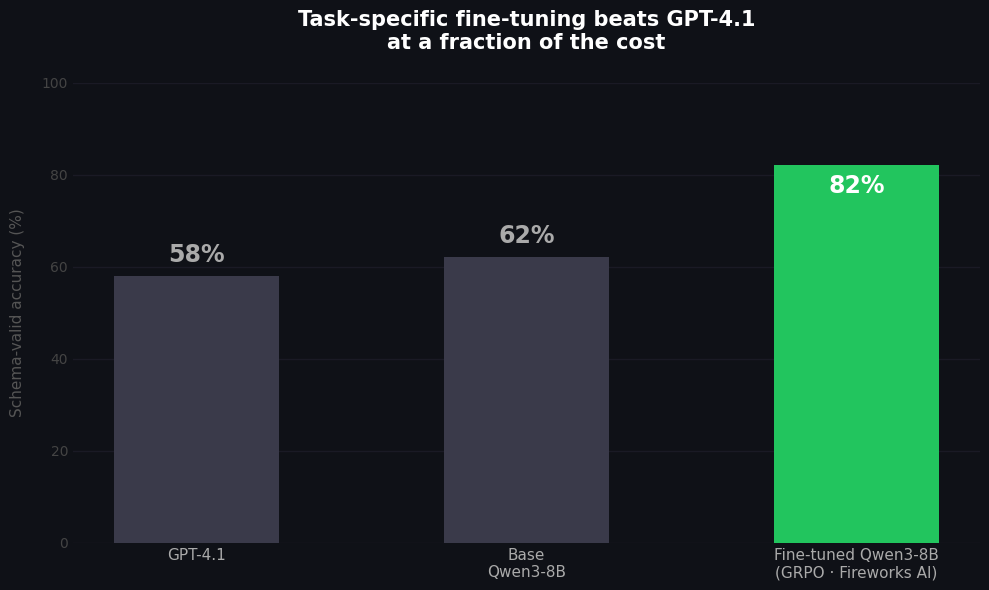

In [33]:
import matplotlib.pyplot as plt

models = ["GPT-4.1", "Base\nQwen3-8B", "Fine-tuned Qwen3-8B\n(GRPO · Fireworks AI)"]
scores = [58, 62, 82]
colors = ["#3A3A4A", "#3A3A4A", "#22C55E"]
text_colors = ["#AAAAAA", "#AAAAAA", "#FFFFFF"]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0F1117")
ax.set_facecolor("#0F1117")

bars = ax.bar(models, scores, color=colors, width=0.5, zorder=2, edgecolor="none")

for bar, s, tc in zip(bars, scores, text_colors):
    ypos = bar.get_height() - 7 if tc == "#FFFFFF" else bar.get_height() + 2
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        ypos,
        f"{s}%",
        ha="center", va="bottom",
        fontsize=17, fontweight="bold", color=tc
    )

ax.set_ylim(0, 100)
ax.set_title(
    "Task-specific fine-tuning beats GPT-4.1\nat a fraction of the cost",
    fontsize=15, fontweight="bold", color="#FFFFFF", pad=24, loc="center"
)

ax.set_ylabel("Schema-valid accuracy (%)", fontsize=11, color="#555555", labelpad=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="y", colors="#444444", length=0, labelsize=10)
ax.tick_params(axis="x", colors="#AAAAAA", length=0, labelsize=11)
ax.yaxis.grid(True, color="#1A1A25", zorder=0, linewidth=1)
ax.set_axisbelow(True)
ax.set_yticks([0, 20, 40, 60, 80, 100])

plt.tight_layout()
plt.savefig("eval_chart.png", dpi=200, bbox_inches="tight", facecolor="#0F1117")
plt.show()

---
## Step 7 - Inference on the Deployed Model

Call the fine-tuned model on a new invoice via the Fireworks inference endpoint.

In [ ]:
raw_invoice_text = """
Bill from Meridian Office Supplies, dated March 15 2024, total $3,420.00 USD.
"""

response = fw_inf_client.chat.completions.create(
    model=f"accounts/{ACCOUNT_ID}/deployments/invoice-extractor-v1",
    messages=[
        {"role": "system", "content": "Extract the following fields from this invoice: vendor, date, amount, currency. Return only a valid JSON object. No markdown, no explanation, no bullet points. Just JSON."},
        {"role": "user", "content": raw_invoice_text}
    ],
    temperature=0.0,
    max_tokens=512,
)

output = response.choices[0].message.content
if "</think>" in output:
    output = output.split("</think>")[-1].strip()

print("Output:")
print(output)
print("\nParsed:")
print(json.dumps(json.loads(output), indent=2))
print(f"\nSchema valid: {score(output) == 1.0} ✓")

Output:
{"vendor": "Meridian Office Supplies", "date": "2024-03-15", "amount": 3420.00, "currency": "USD"}

Parsed:
{
  "vendor": "Meridian Office Supplies",
  "date": "2024-03-15",
  "amount": 3420.0,
  "currency": "USD"
}

Schema valid: True ✓
